# Projet de Machine Learning 

In [1]:
# Chargement des librairies nécessaires
library(ggplot2)
library(tidyverse)
library(gridExtra)
library(GGally)
library(plotly)
library(corrplot)
library(reshape2)
library(FactoMineR) 
library(factoextra)
library(glmnet) 
library(ggfortify)
library(pROC)
library(ROCR)

Warning message:
“le package ‘ggplot2’ a été compilé avec la version R 4.4.3”
Warning message:
“le package ‘readr’ a été compilé avec la version R 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachement du package : ‘gridExtra’


L'objet suivant est masqué depuis ‘package:dplyr’:

    combine


Warning message:
“le package ‘plotly’ a été compilé avec la version R 4.4.3”

Attachement du package : ‘plotly’


L'objet suivant est masqué depuis ‘package:ggplot2’:

    last_plot


L'objet suivant est masqué depuis ‘package:stats’:

   

## Introduction


## Présentation du jeu de données 

Les données ont été extraites et mises en forme, elles sont décrites par les variables suivantes :
* **Patient_ID** : identifiant unique pour chaque patient ;  
* **Age** : âge du patient (en années) ;  
* **Gender** : genre du patient ; qualitative à deux modalités ;  
* **Height_cm** : taille du patient en centimètres ;  
* **Weight_kg** : poids du patient en kilogrammes ;  
* **BMI** : indice de masse corporelle (IMC), calculé à partir de la taille et du poids (kg/m²) ;  
* **Systolic_BP** : pression artérielle systolique (mmHg) ;  
* **Diastolic_BP** : pression artérielle diastolique (mmHg) ;  
* **Cholesterol_Total** : cholestérol sérique total (mg/dL) ;  
* **Cholesterol_LDL** : lipoprotéines de basse densité (« mauvais » cholestérol) (mg/dL) ;  
* **Cholesterol_HDL** : lipoprotéines de haute densité (« bon » cholestérol) (mg/dL) ;  
* **Fasting_Blood_Sugar** : taux de glycémie à jeun (mg/dL) ;  
* **Smoking_Status** : statut tabagique ; qualitative à deux modalités ;  
* **Alcohol_Consumption** : niveau de consommation d’alcool ; qualitative à trois modalités ;  
* **Physical_Activity_Level** : niveau d’activité physique ; qualitative à quatre modalités ;  
* **Family_History** : antécédents familiaux de maladie cardiaque ; qualitative à deux modalités ;  
* **Stress_Level** : niveau de stress auto-déclaré ; échelle de 1 à 10 ;  
* **Sleep_Hours** : nombre moyen d’heures de sommeil par nuit ;  
* **Heart_Disease_Risk** : risque d’accident cardiaque ; qualitative à deux modalités : 0 (risque faible) ou 1 (risque élevé).  

In [2]:
# Lecture des données
# path="http://www.math.univ-toulouse.fr/~besse/Wikistat/data/"
path <- "./"
data <- read.table(paste(path, "healthcare_synthetic_data.csv", sep = ""),
                    sep = ",", header = TRUE)
# Premières lignes du jeu de données !!
head(data)
# Vérification du contenu
#summary(data)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


## Prise en charge des données


In [3]:
# Changement du type des variables qualitatives en facteur
data[, "Gender"] <- as.factor(data[,"Gender"])
data[, "Smoking_Status"] <- as.factor(data[, "Smoking_Status"])
data[, "Alcohol_Consumption"] <- as.factor(data[, "Alcohol_Consumption"])
data[, "Family_History"] <- as.factor(data[, "Family_History"])
data[, "Heart_Disease_Risk"] <- as.factor(data[, "Heart_Disease_Risk"])
data[, "Physical_Activity_Level"] <- as.factor(data[, "Physical_Activity_Level"])


# Premières lignes du jeu de données !!
head(data)
# Vérification du contenu
summary(data)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<int>,<int>,<fct>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


  Patient_ID             Age        Gender     Height_cm       Weight_kg     
 Length:15000       Min.   :25.00   0:7622   Min.   :138.5   Min.   : 33.70  
 Class :character   1st Qu.:46.00   1:7378   1st Qu.:158.5   1st Qu.: 65.20  
 Mode  :character   Median :55.00            Median :164.7   Median : 73.90  
                    Mean   :54.54            Mean   :165.3   Mean   : 75.25  
                    3rd Qu.:63.00            3rd Qu.:172.0   3rd Qu.: 83.90  
                    Max.   :85.00            Max.   :198.1   Max.   :150.10  
      BMI         Systolic_BP     Diastolic_BP    Cholesterol_Total
 Min.   :14.50   Min.   : 90.0   Min.   : 60.00   Min.   :127.0    
 1st Qu.:24.50   1st Qu.:127.0   1st Qu.: 85.00   1st Qu.:201.0    
 Median :27.20   Median :135.0   Median : 91.00   Median :216.0    
 Mean   :27.45   Mean   :135.1   Mean   : 90.54   Mean   :216.2    
 3rd Qu.:30.00   3rd Qu.:143.0   3rd Qu.: 96.00   3rd Qu.:231.0    
 Max.   :46.10   Max.   :182.0   Max.   :120.0

## Exploration élémentaire

### Analyse descriptive unidimensionnelles
#### Variables quantitatives continues
##### Symétrie des variables quantitatives

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


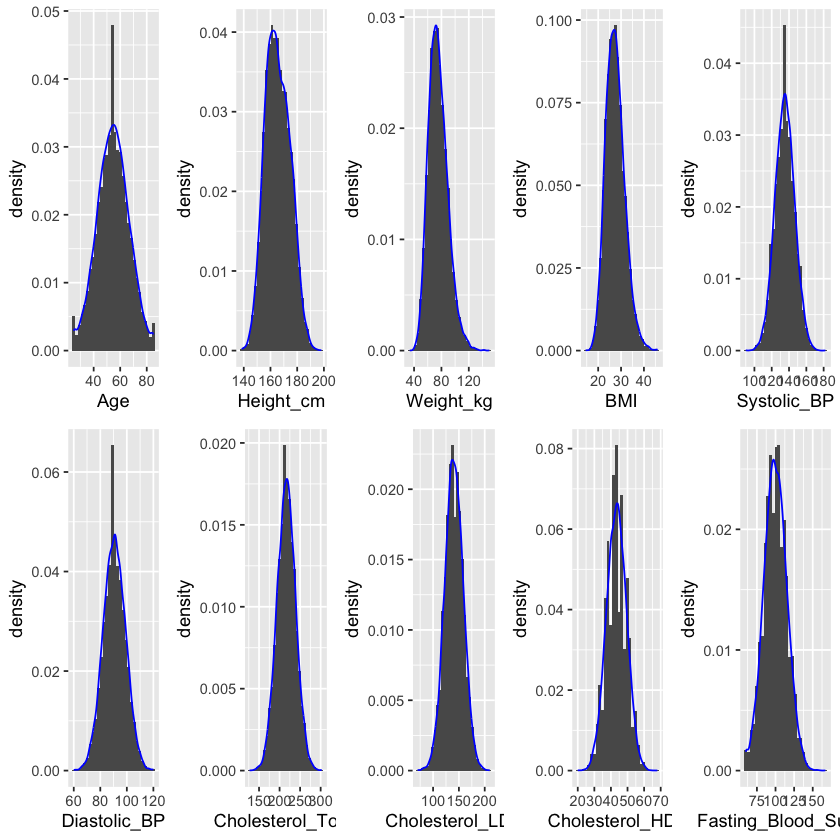

In [4]:

g1<-ggplot(data,aes(x=Age))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue") 
g2<-ggplot(data,aes(x=Height_cm))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g3<-ggplot(data,aes(x=Weight_kg))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g4<-ggplot(data,aes(x=BMI))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g5<-ggplot(data,aes(x=Systolic_BP))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g6<-ggplot(data,aes(x=Diastolic_BP))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g7<-ggplot(data,aes(x=Cholesterol_Total))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g8<-ggplot(data,aes(x=Cholesterol_LDL))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g9<-ggplot(data,aes(x=Cholesterol_HDL))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g10<-ggplot(data,aes(x=Fasting_Blood_Sugar))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
#g11<-ggplot(data,aes(x=Stress_Level))+
#  geom_histogram(aes(y=after_stat(density)))+
#  geom_density(alpha=.2, col="blue")
#g12<-ggplot(data,aes(x=Sleep_Hours))+
# geom_histogram(aes(y=after_stat(density)))+
# geom_density(alpha=.2, col="blue")

grid.arrange(g1,g2,g3, g4, g5, g6, g7, g8, g9, g10, ncol=5, nrow=2)
rm(g1,g2,g3,g4,g5,g6,g7,g8, g9, g10)

##### Transformation des variables 

##### Corrélations des variables 

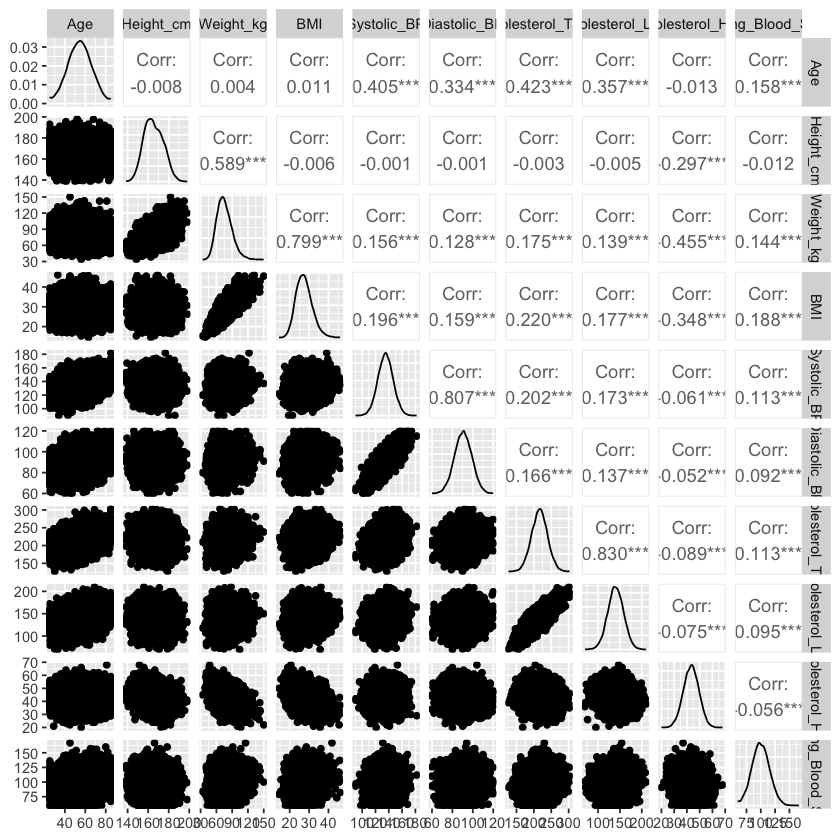

In [10]:
ggpairs(data[, c(2,4:12)])

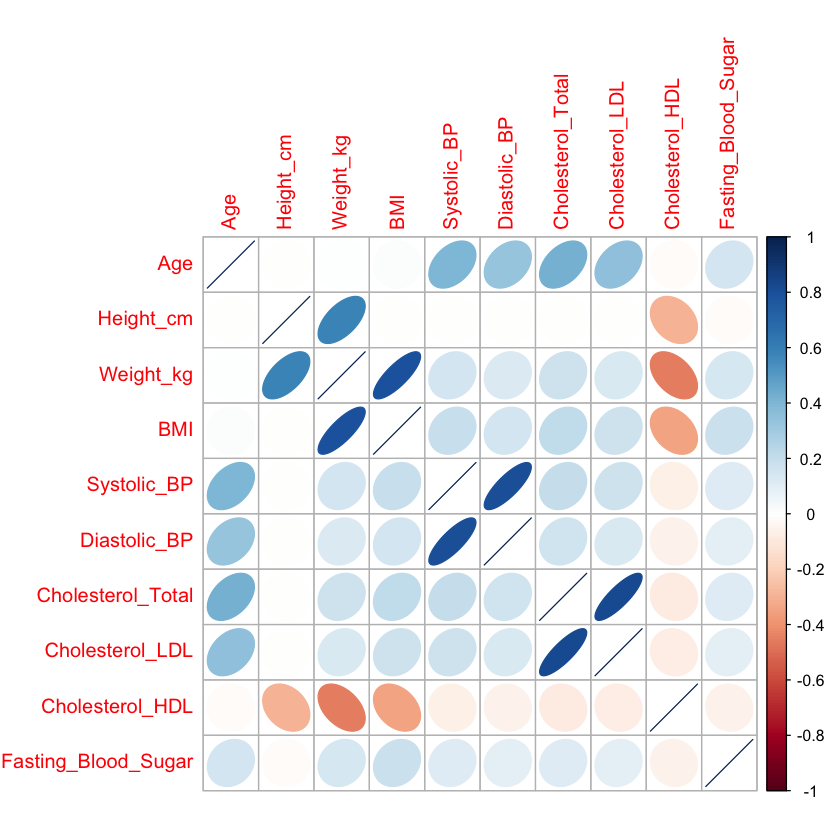

In [11]:
corrplot(cor(data[, c(2,4:12)]),method="ellipse")

#### Variables quantitatives discrètes

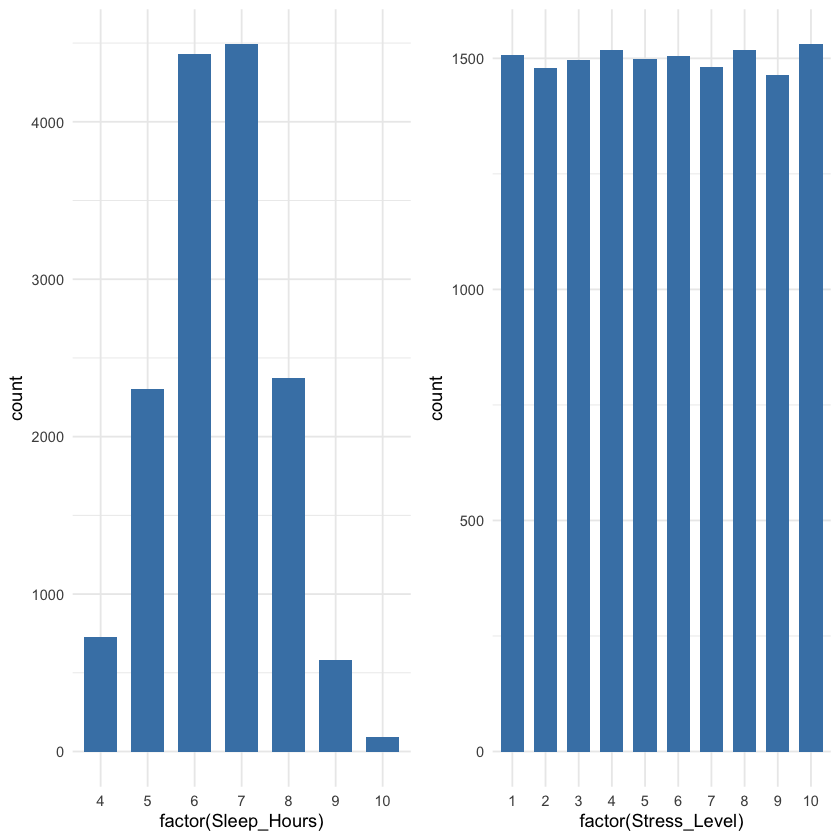

In [31]:
g1 <- ggplot(data, aes(x=factor(Sleep_Hours)))+
  geom_bar(stat="count", width=0.7, fill="steelblue")+
  theme_minimal()

g2 <- ggplot(data, aes(x=factor(Stress_Level)))+
  geom_bar(stat="count", width=0.7, fill="steelblue")+
  theme_minimal()

grid.arrange(g1, g2, ncol = 2)
rm(g1, g2)


### Analyse descriptive bidimensionnelles


### ACP

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
“Ignoring empty aesthetic: `width`.”


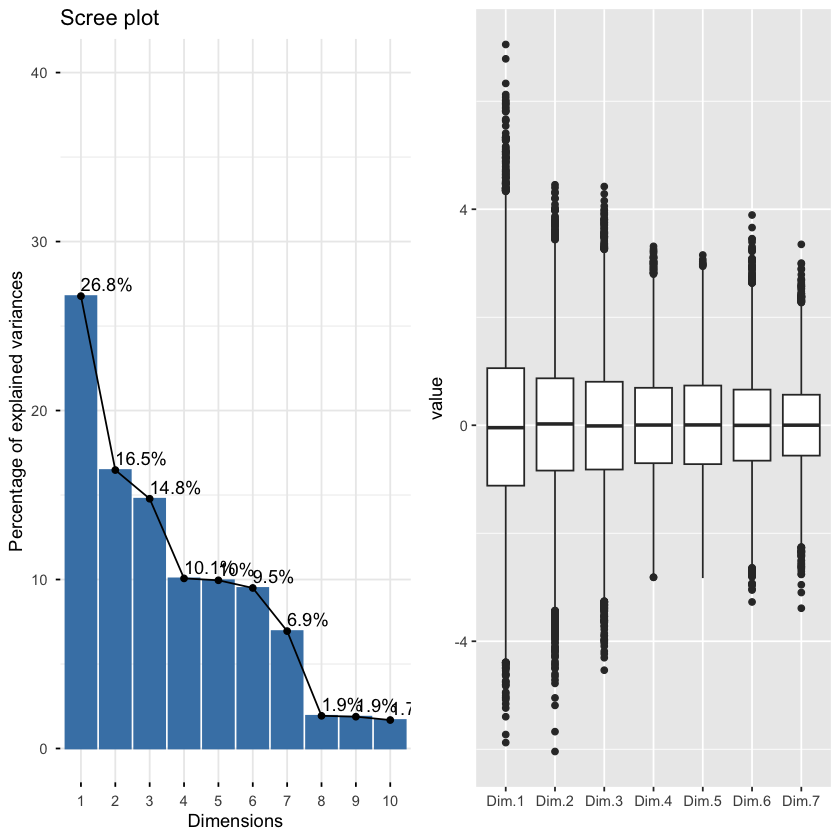

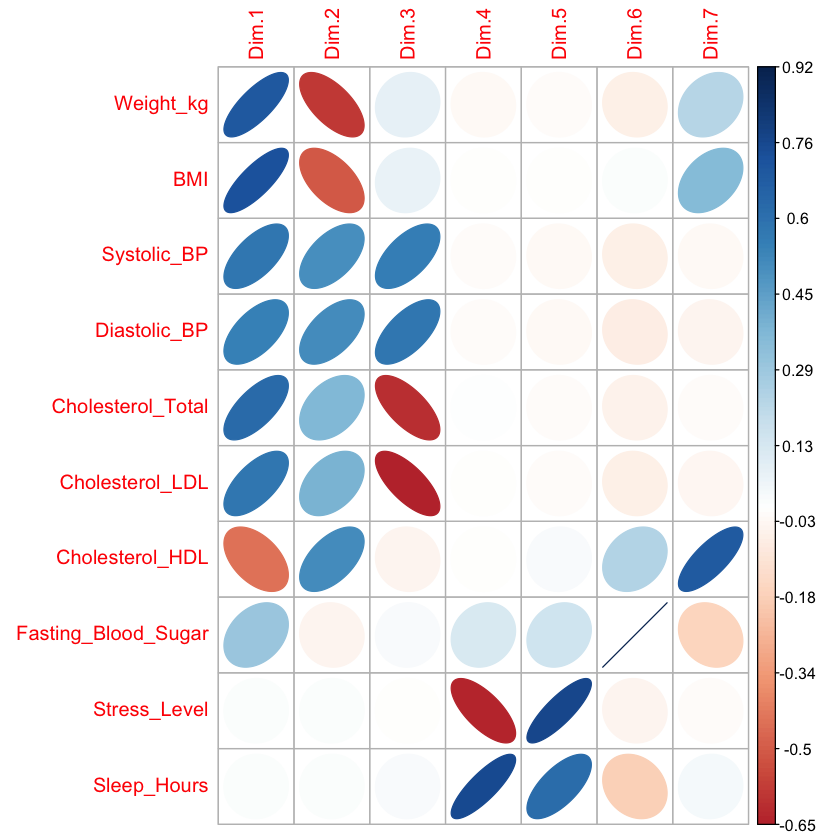

In [12]:
dataquant = data[, c(2,c(4:12,17,18))]
acp <- PCA(dataquant, scale.unit = TRUE,
           graph = FALSE, quali.sup = 1, quanti.sup = 2, ncp = 7)
# Décroissance des valeurs propres
g1<-fviz_eig(acp, addlabels = TRUE, ylim = c(0, 40))
library(reshape2)
g2<-ggplot(melt(acp$ind$coord),aes(x=Var2,y=value))+
  geom_boxplot()+
  xlab("")
grid.arrange(g1,g2,ncol=2)

corrplot(acp$var$cor, is.corr=FALSE,method="ellipse")

Si on garde 4 dim : 68.21 % de la variations est représentée

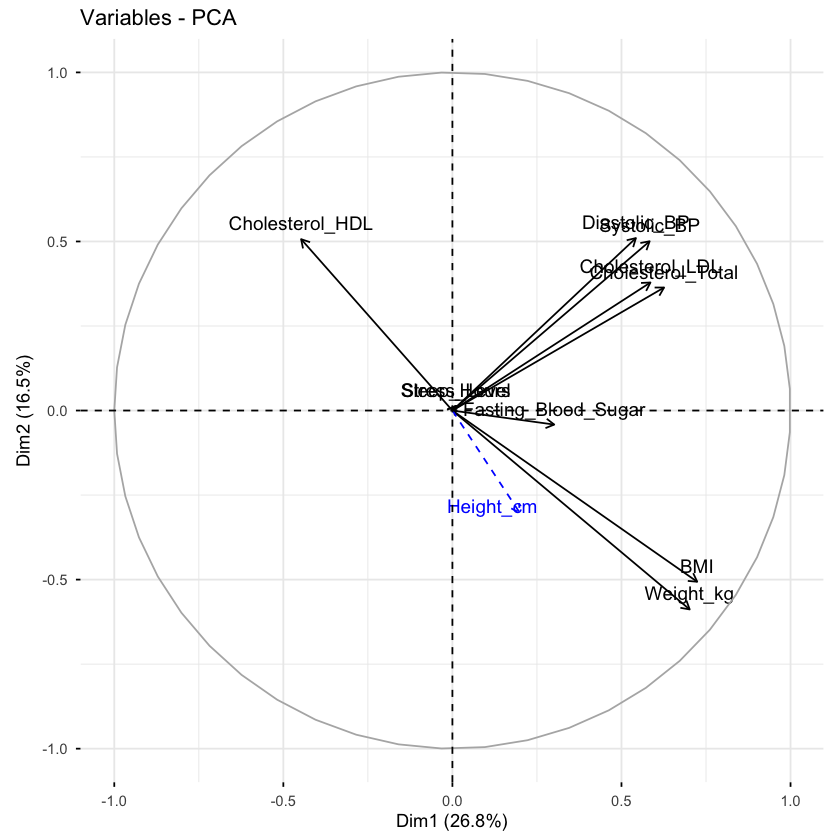

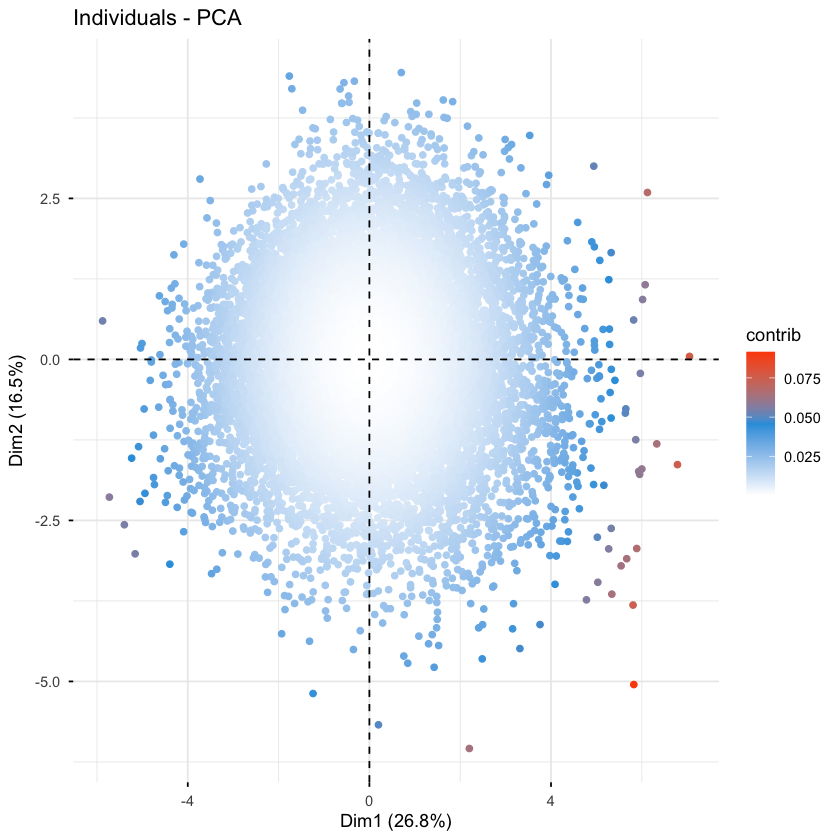

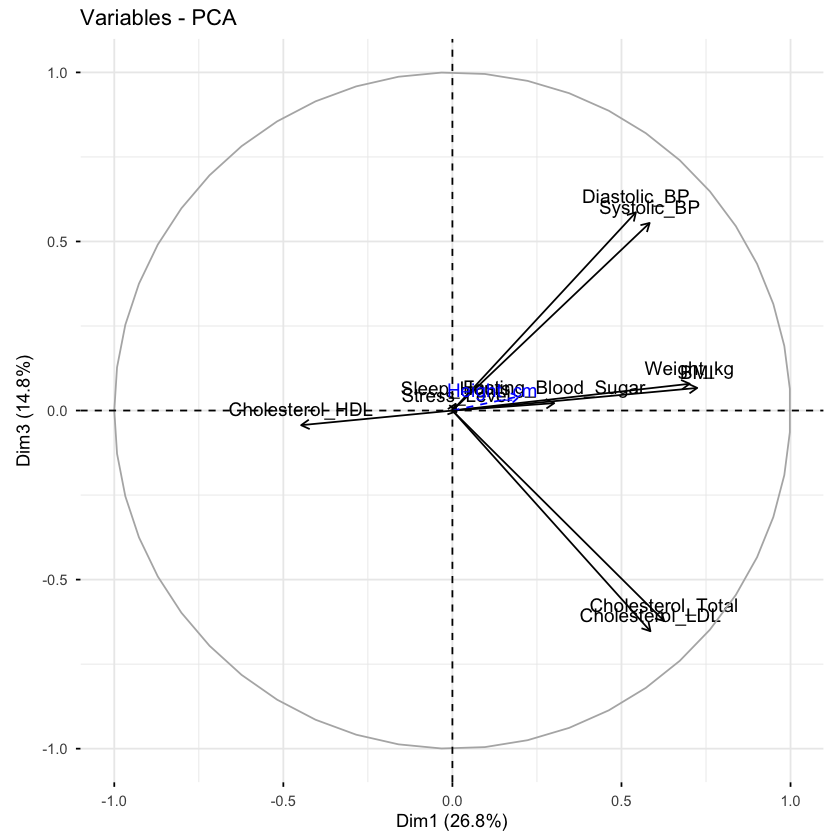

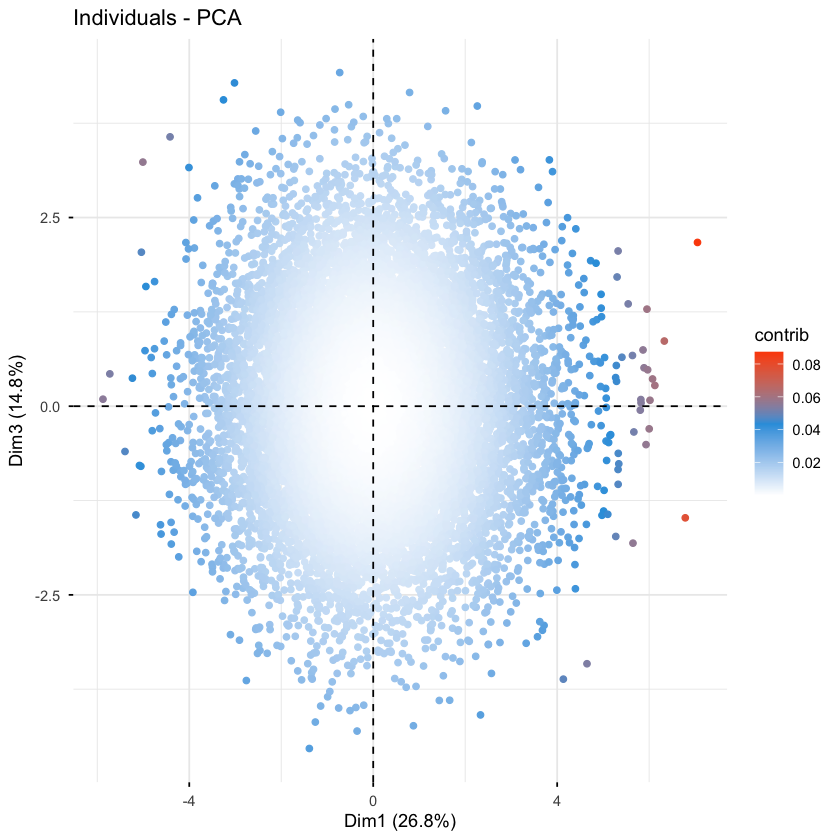

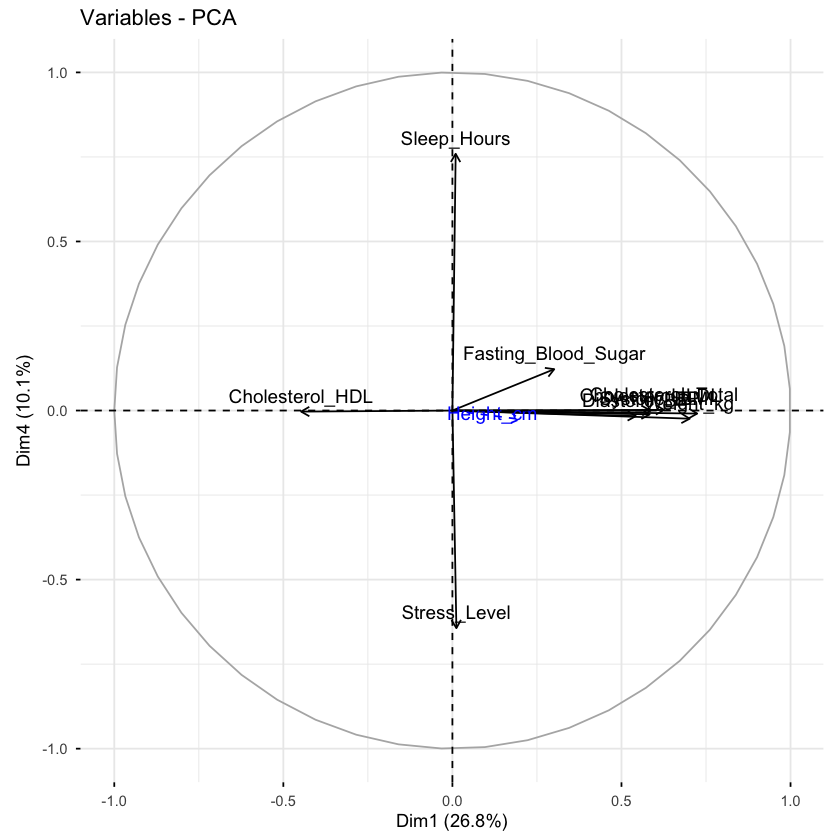

In [16]:
fviz_pca_var(acp)
fviz_pca_ind(acp,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ))
fviz_pca_var(acp,axes=c(1,3))
fviz_pca_ind(acp,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ),axes=c(1,3))
fviz_pca_var(acp,axes=c(1,4))